Import all required libraries and load the raw car evaluation dataset.

In [9]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df = pd.read_csv('dataset/cars_classification_dataset.csv')
df.head()

,buying,maint,doors,persons,lug_boot,safety,car
0,vhigh,vhigh,two,two,small,low,unacc
1,vhigh,vhigh,two,two,small,med,unacc
2,vhigh,vhigh,two,two,small,high,unacc
3,vhigh,vhigh,two,two,med,low,unacc
4,vhigh,vhigh,two,two,med,med,unacc


Split the raw data into train and test sets using stratified sampling to preserve the class proportions in both splits. Then build a pipeline that ordinal-encodes the six categorical features in their natural order, applies SMOTE only on the training data, and trains a Logistic Regression classifier. The pipeline is fit on the training set and predictions are made on the untouched test set.

In [5]:
X = df.drop(columns=['car'])
y = df['car']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

categories = [
    ['low', 'med', 'high', 'vhigh'],      # buying
    ['low', 'med', 'high', 'vhigh'],      # maint
    ['two', 'three', 'four', '5more'],    # doors
    ['two', 'four', 'more'],              # persons
    ['small', 'med', 'big'],              # lug_boot
    ['low', 'med', 'high'],               # safety
]

pipeline = Pipeline([
    ('encoder',    OrdinalEncoder(categories=categories)),
    ('smote',      SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

Evaluate the trained model on the original test set. Print the overall accuracy and a confusion matrix with a fixed class order from worst to best acceptability.

Accuracy: 0.8092
Confusion matrix:
[[193  35   9   5]
 [ 11  61   1   4]
 [  0   0  14   0]
 [  0   1   0  12]]


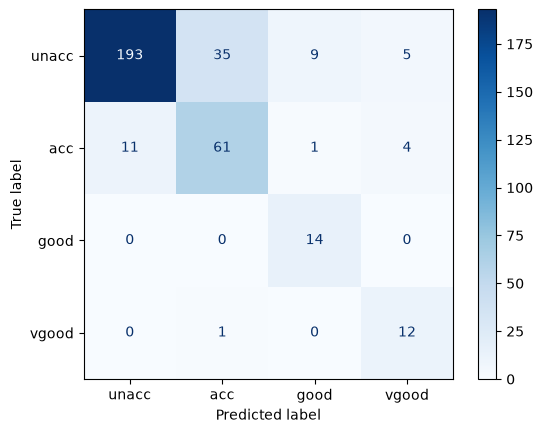

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=['unacc', 'acc', 'good', 'vgood'])
print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['unacc', 'acc', 'good', 'vgood'],
    cmap='Blues'
)
plt.show()

Persist the entire trained pipeline to disk with joblib so it can be reloaded later for computing additional metrics without retraining. Saving the pipeline (not just the classifier) means the encoder and its learned mappings travel with the model.

In [11]:
import joblib

joblib.dump(pipeline, 'log_reg_model.joblib')

['log_reg_model.joblib']